# Experiment 1

Idea: With a given probability randomly allocate price within the range otherwise give
best action as suggested by policy

In [20]:
import gymnasium as gym
import pandas as pd
import numpy as np
from stable_baselines3.ppo import PPO
import seaborn as sns
import matplotlib.pyplot as plt
import copy

from fair_dynamic_pricing_with_rl.utils.env import FMCGEnv
from fair_dynamic_pricing_with_rl.utils.demand_model import DemandModelEstimator

In [21]:
unit_sales = pd.read_csv("../data/sales_train_evaluation.csv")
prices = pd.read_csv("../data/sell_prices.csv")
calendar = pd.read_csv("../data/calendar.csv")

In [22]:
demand_model_estimator = DemandModelEstimator(
    unit_sales_df = unit_sales,
    prices_df = prices,
    calendar_df = calendar,
    price_granularity = 0.001,
    verbose = True
)

demand_model_parameters = demand_model_estimator.run_pipeline()

--- Fitting demand model for FOODS_1_096 ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.638
Model:                            OLS   Adj. R-squared:                  0.636
Method:                 Least Squares   F-statistic:                     325.1
Date:                Sun, 26 Jul 2026   Prob (F-statistic):          1.13e-279
Time:                        14:05:58   Log-Likelihood:                -3366.3
No. Observations:                1300   AIC:                             6749.
Df Residuals:                    1292   BIC:                             6790.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [49]:
# Register the environment so we can create it with gym.make()
gym.register(
    id="gymnasium_env/FMCGEnv",
    entry_point=FMCGEnv,
    max_episode_steps=500,  # Prevent infinite episodes
)

c:\Users\Kim Levente\AppData\Local\Programs\Python\Python313\Lib\site-packages\gymnasium\envs\registration.py:637: UserWarning: WARN: Overriding environment gymnasium_env/FMCGEnv already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [73]:
env = gym.make("gymnasium_env/FMCGEnv",
               p_min=np.array([5.0,5.0]),
               p_max=np.array([9.0,9.0]),
               p_diff=np.array([0.01,0.01]),
               betas=[params.to_numpy() for params in demand_model_parameters[3]],
               max_demand=demand_model_parameters[4],
               n_snap_days=10,
               calendar_seed=42,
               noise_range=1
               )

In [74]:
# PPO hyperparameters from Liu et al. (2024)
model = PPO(policy="MultiInputPolicy",
            env=env,
            learning_rate=0.0001,
            batch_size=64, # default
            clip_range=0.2, # default
            seed=42)

# no warm-up following Liu et al. (2024)
# model.learn(total_timesteps=25000,
#             progress_bar=True)

In [ ]:
def running_model(env1,
                  alg,
                  T,
                  K,
                  num_products,
                  random_action_prob=0.5,
                  seed=None
                  ):
    """ PPO algorithm with some probability of choosing an action randomly.

    Args:
        env1 (FMCGEnv): the define gym environment
        alg (stable_baselines3.PPO): PPO policy
        T (int): number of timesteps per episode
        K (int): number of episodes
        num_products (int): number of products
        random_action_prob (float): probability of choosing random action (\in [0.0-1.0])
        seed (int): seed for reproducibility

    Returns:
        rew (np.ndarray): rewards (T,K)
        action_hist (np.ndarray): action history (T,K,L)
        groups (np.ndarray): groups according to binary sensitive attribute (T,K)
    """

    env = copy.deepcopy(env1)

    # dedicated RNG for random action override plus seeding action sampler
    rng = np.random.default_rng(seed)
    env.action_space.seed(seed)

    rew = np.zeros((T,K))
    action_hist = np.zeros((T,K,num_products))
    groups = np.zeros((T,K))

    for k in range(K):
        # sample initial state
        # seed each reset deterministically but distinctly per episode
        observation, info = env.reset(seed=None if seed is None else seed + k)

        #record reward received over episode
        eprew = 0.0
        for t in range(T):
            # save the group wrt. sensitive attribute
            groups[t,k] = observation['sensitive_attr']
            
            # take action using trained model
            action, _states = alg.predict(observation, deterministic=False)
            a = np.asarray(action)
            
            # with random_action_prob override with a random action
            if rng.random() < random_action_prob:
                a = env.action_space.sample()
                a = np.asarray(a)
            
            action_hist[t,k] = a

            # record new state/reward from action played
            observation, reward, terminated, truncated, info = env.step(a)
            eprew += reward

            rew[t,k] = reward
        
    return rew, action_hist, groups

In [ ]:
def compute_jains_index(action_hist, groups, rew, p_min, p_diff):
    """
    Compute Jain's fairness index across sensitive-attribute (SNAP-proxied) groups.

    Args:
        action_hist (np.ndarray): raw action indices taken by the policy (T,K,L)
        groups (np.ndarray): sensitive attribute labels (0/1) (T,K)
        rew (np.ndarray): realized rewards (T,K)
        p_min (np.ndarray): minimum prices (L)
        p_diff (np.ndarray) price granularity (L)

    Returns:
        jains_index: float
        group_values: dict {group_label: aggregated_value}
    """
    unique_groups = np.unique(groups)
    group_values = {}

    # get main parameters
    T, K, L = action_hist.shape

    # transform action indices to prices based on _action_to_price method
    # rounding guards against floating point inconsistencies
    prices = np.zeros((T, K, L))
    for product_idx in range(L):
        prices[:,:,product_idx] = np.round(p_min[product_idx] + action_hist[:,:,product_idx] * p_diff[product_idx], 10)

    total_price = prices.sum(axis=2)  # basket price per (t, k)

    for g in unique_groups:
        mask = (groups == g)
        group_values[g] = total_price[mask].mean()

    x = np.array(list(group_values.values()))
    n = len(x)
    jains_index = (x.sum() ** 2) / (n * np.sum(x ** 2))

    return jains_index, group_values

In [105]:
# experiment 1 parameters
random_probs_list = [0.0,0.5,0.7,1.0]
K = 5000
P_MIN = np.array([5.0,5.0])
P_DIFF = np.array([0.01,0.01])

In [106]:
# storing expected mean episode rewards
episode_rewards_comparison = np.zeros((K*len(random_probs_list),3))
# storing Jain's indexes and mean episode revenues
results = pd.DataFrame(np.zeros((len(random_probs_list),3)),columns=["mean_episode_revenue","jains_index","random_action_prob"])

for idx in range(len(random_probs_list)):

    rewards, action_hist, groups = running_model(env1=env,
                                             alg=model,
                                             T=60,
                                             K=K,
                                             num_products=2,
                                             random_action_prob=random_probs_list[idx],
                                             seed=42)
 
    episode_rewards = rewards.sum(axis=0)
    e_mean_episode_reward = episode_rewards.cumsum() / (np.arange(K) + 1)

    # expected mean episode rewards
    episode_rewards_comparison[(idx*K):((idx+1)*K),0] = np.arange(K)
    episode_rewards_comparison[(idx*K):((idx+1)*K),1] = e_mean_episode_reward

    # random action probability
    episode_rewards_comparison[(idx*K):((idx+1)*K),2] = random_probs_list[idx]

    # save main performance metrics
    results.loc[idx,"random_action_prob"] = random_probs_list[idx]
    results.loc[idx,"mean_episode_revenue"] = episode_rewards.mean()
    results.loc[idx, "jains_index"], _ = compute_jains_index(action_hist, groups, rewards, p_min=P_MIN, p_diff=P_DIFF)
 

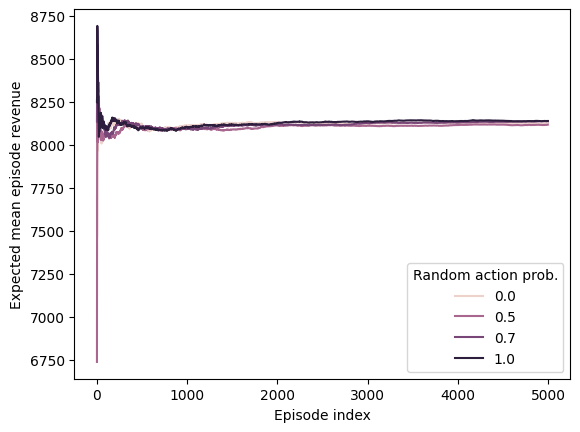

In [109]:
episode_rewards_comparison_df = pd.DataFrame(episode_rewards_comparison,
                                             columns=["episode_idx", "mean_episode_revenue", "random_action_prob"])

# for plotting every episode ex. first x: data = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx > 50.0],
sns.lineplot(data = episode_rewards_comparison_df,
             x="episode_idx",
             y="mean_episode_revenue",
             hue="random_action_prob")
plt.xlabel("Episode index")
plt.ylabel("Expected mean episode revenue")
plt.legend(title="Random action prob.")
plt.show()

In [117]:
# edge of pure PPO over baseline completely random algorithm wrt mean episode revenue over all episodes
mean_episode_revenues = episode_rewards_comparison_df.loc[episode_rewards_comparison_df.episode_idx==999,:]
mean_episode_revenue_ppo = mean_episode_revenues.loc[mean_episode_revenues.random_action_prob==0.0, "mean_episode_revenue"].to_numpy()[0]
mean_episode_revenue_random = mean_episode_revenues.loc[mean_episode_revenues.random_action_prob==1.0, "mean_episode_revenue"].to_numpy()[0]

print(f"Pure PPO achieved a mean per-episode reward of {mean_episode_revenue_ppo:.4f}, while the truly random policy: {mean_episode_revenue_random:.4f}.")
print(f"This represents an {(mean_episode_revenue_ppo/mean_episode_revenue_random-1)*100:.2f}% edge for the pure PPO policy over truly random.")

Pure PPO achieved a mean per-episode reward of 8109.6558, while the truly random policy: 8100.6382.
This represents an 0.11% edge for the pure PPO policy over truly random.


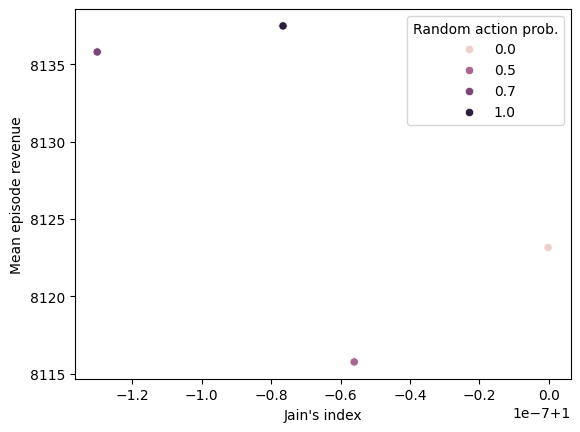

In [120]:
sns.scatterplot(data=results, x="jains_index", y="mean_episode_revenue",
                hue="random_action_prob")
plt.xlabel("Jain's index")
plt.ylabel("Mean episode revenue")
plt.legend(title="Random action prob.")
plt.show()